# Jupyter Notebook for Validating Bambu TPU Structures
Import libraries

In [85]:
import csv
import numpy as np
from scipy.interpolate import interp1d
from Force_Disp import force_disp
from Stiffnesses import k_fl, k_Al
from matplotlib import pyplot as plt
from TensegritySim import Node, Connection, Tensegrity, TensegritySolver
from TensegritySim import ConnectionNonlinear, NonlinProps

Masses = np.arange(0., 651., 50) # Masses in grams
Forces = Masses / 1000. * 9.8 # Convert to Newtons
print("Forces:", Forces)

Disp = np.linspace(0., 50./100.*68.12, 15001) # Displacements in mm

string = Connection.ConnectionType.STRING
bar = Connection.ConnectionType.BAR

Forces: [0.   0.49 0.98 1.47 1.96 2.45 2.94 3.43 3.92 4.41 4.9  5.39 5.88 6.37]


## Array 8
Sheets 15--17?


In [81]:
# Read in time, displacement, and force data for specimens 15--17
# Convert to cable dimensions (Force in N, Displacement in mm)
Disp_15, Force_15 = force_disp("Tables/Bambu TPU sheet_15.csv")
Disp_16, Force_16 = force_disp("Tables/Bambu TPU sheet_16.csv")
Disp_17, Force_17 = force_disp("Tables/Bambu TPU sheet_17.csv")

# plt.figure(0)
# plt.plot(Disp_15, Force_15, label="Specimen 15")
# plt.plot(Disp_16, Force_16, label="Specimen 16")
# plt.plot(Disp_17, Force_17, label="Specimen 17")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.title("Raw Force-Displacement Data")
# plt.legend()
# plt.show()
# plt.close()

In [82]:
# Resample the force-displacement data
f15 = interp1d(Disp_15, Force_15, kind='cubic', fill_value="extrapolate")
f16 = interp1d(Disp_16, Force_16, kind='cubic', fill_value="extrapolate")
f17 = interp1d(Disp_17, Force_17, kind='cubic', fill_value="extrapolate")

Force_15 = f15(Disp)
Force_16 = f16(Disp)
Force_17 = f17(Disp)

# plt.figure(1)
# plt.plot(Disp, Force_15, label="Specimen 15")
# plt.plot(Disp, Force_16, label="Specimen 16")
# plt.plot(Disp, Force_17, label="Specimen 17")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.title("Resampled Force-Displacement Data")
# plt.legend()
# plt.show()
# plt.close()

In [83]:
# Average the data
avg_8 = (Force_15 + Force_16 + Force_17) / 3.

# plt.plot(Disp, avg_8, label="Avg Specimens 15--17")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.show()
# plt.close()

Verify that the Odgen parameters are correct by plotting the stress-strain curve

In [84]:
strain = Disp / 68.12 # mm/mm
stress = avg_8 / 1.2**2 # N/mm^2

node01 = Node(name="NodeA0", position=np.array([0., 0.]))
node02 = Node(name="NodeB0", position=np.array([1., 0.]))
connection0 = ConnectionNonlinear(nodes=[node01, node02], connection_type=string, material_properties=NonlinProps(strain=strain, stress=stress))
mu1 = connection0.material_properties.ogden_params[0]
alpha1 = connection0.material_properties.ogden_params[1]
mu2 = connection0.material_properties.ogden_params[2]
alpha2 = connection0.material_properties.ogden_params[3]
mu3 = connection0.material_properties.ogden_params[4]
alpha3 = connection0.material_properties.ogden_params[5]
print(f"Ogden parameters: mu1 = {mu1:.4f}, alpha1 = {alpha1:.4f}, mu2 = {mu2:.4f}, alpha2 = {alpha2:.4f}, mu3 = {mu3:.4f}, alpha3 = {alpha3:.4f}")
stretch = 1. + strain
stress_true = mu1 * (stretch**alpha1 - stretch**(-alpha1/2.))
stress_true += mu2 * (stretch**alpha2 - stretch**(-alpha2/2.))
stress_true += mu3 * (stretch**alpha3 - stretch**(-alpha3/2.))
stress_eng = stress_true / stretch

plt.plot(strain, stress, label="Measured data")
plt.plot(strain, stress_eng, label="Ogden material model")
plt.xlabel("Strain (mm/mm)")
plt.ylabel("Stress (N/mm^2)")
plt.title("Stress-Strain Curves")
plt.legend()
plt.show()
plt.close()

KeyboardInterrupt: 

Read in positions for Array 8

In [ ]:
pos8 = [56.4] # initial position in mm
with open("Tables/Array 8.csv", "r", newline="") as csvfile8:
    reader = csv.DictReader(csvfile8)
    for i, row in enumerate(reader):
        if i % 3 == 0:  # every third row (starting with the first)
            pos8.append(float(row["Inner Distance (mm)"])) # mm
# pos8.append(41.3) # Going past the max displacement to observe behavior
pos8 = np.array(pos8) # convert list to numpy array
pos8 = np.round(pos8, 1) # round to nearest tenth
pos8 += 11.7 # add the width of the TPU to the inner distance
print("Displacements for Array 8 (mm):", pos8)

Displacements for Array 8 (mm): [68.1 67.5 67.2 66.3 66.  64.3 64.3 63.1 61.6 60.3 58.8 58.1 55.2 53.9]


In [ ]:
points = []
ks = []
errors = []
min_error = np.inf
# For Array 8 we used 801 to 1101 by 10s
for num_points in range(51, 152, 1):
    points.append(num_points) # Store number of points used
    k_TPU = np.polyfit(Disp[:num_points+1], avg_8[:num_points+1], 1)[0] # Linear stiffness in N/mm
    ks.append(k_TPU)
    if k_TPU < 0.01:
        k_TPU = 0.01 # prevent zero stiffness
    
    node1 = Node(name="A", position=np.array([0., 0.]))
    node2 = Node(name="B", position=np.array([68.1, 0.]))
    node3 = Node(name="C", position=np.array([68.1, 68.1]))
    node4 = Node(name="D", position=np.array([0., 68.1]))
    nodes = [node1, node2, node3, node4]

    connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, name="control_string")
    connection2 = Connection(nodes=[node2, node3], connection_type=string, stiffness=k_TPU)
    connection3 = Connection(nodes=[node3, node4], connection_type=string, stiffness=k_TPU)
    connection4 = Connection(nodes=[node4, node1], connection_type=string, stiffness=k_TPU)
    connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
    connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
    connections = [connection1, connection2, connection3, connection4, connection5, connection6]

    pins = {"A": [True, True],
            "B": [False, True],
            "C": [False, False],
            "D": [False, False]}
    
    controls = [connection1]

    tensegrity_system = Tensegrity(nodes, connections, pins, controls)
    solver = TensegritySolver(tensegrity_system)
    solver.solve()

    length_change = 0.0 # mm, initialize length change
    tensions = []
    for i in range(len(pos8)):
        tensegrity_system.change_control_lengths(length_change)
        solver.solve()
        tensions.append(connection1.force)
        if i < len(pos8) - 1:
            length_change = pos8[i+1] - pos8[i] # mm

    error = np.sqrt(np.mean((np.array(tensions) - Forces)**2)) # RMSE
    errors.append(error)
    if error < min_error:
        min_error = error
        best_k = k_TPU
        best_num_points = num_points
        best_tensions = tensions
# Return the value of N and the stiffness that gives the minimum error
print("Best number of points used:", best_num_points)
print("Best stiffness (N/mm):", best_k)
print("Best error:", min_error)

Best number of points used: 96
Best stiffness (N/mm): 1.4253727217708811
Best error: 0.6870543224165139


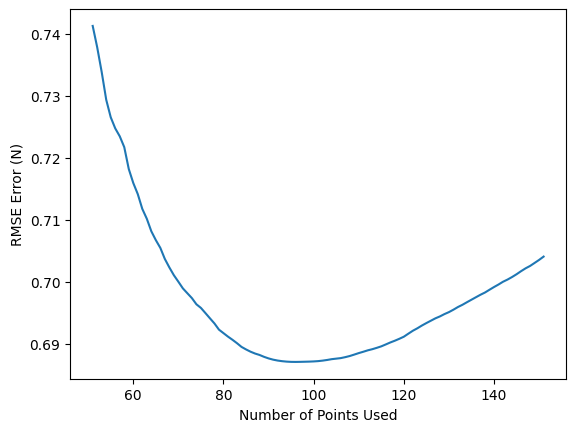

In [ ]:
plt.plot(points, errors)
plt.xlabel("Number of Points Used")
plt.ylabel("RMSE Error (N)")
plt.show()
plt.close()

### Ogden material model

In [ ]:
node1 = Node(name="A", position=np.array([0., 0.]))
node2 = Node(name="B", position=np.array([68.1, 0.]))
node3 = Node(name="C", position=np.array([68.1, 68.1]))
node4 = Node(name="D", position=np.array([0., 68.1]))
nodes = [node1, node2, node3, node4]

connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, name="control_string")
connection2 = ConnectionNonlinear(nodes=[node2, node3], connection_type=string, material_properties=NonlinProps(strain, stress))
connection3 = ConnectionNonlinear(nodes=[node3, node4], connection_type=string, material_properties=NonlinProps(strain, stress))
connection4 = ConnectionNonlinear(nodes=[node4, node1], connection_type=string, material_properties=NonlinProps(strain, stress))
connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
connections = [connection1, connection2, connection3, connection4, connection5, connection6]

pins = {"A": [True, True],
        "B": [False, True],
        "C": [False, False],
        "D": [False, False]}
    
controls = [connection1]

tensegrity_system = Tensegrity(nodes, connections, pins, controls)
solver = TensegritySolver(tensegrity_system)
solver.solve()

length_change = 0.0 # mm, initialize length change
tensions_NL_8 = []
for i in range(len(pos8)):
    tensegrity_system.change_control_lengths(length_change)
    solver.solve()
    tensions_NL_8.append(connection1.force)
    if i < len(pos8) - 1:
        length_change = pos8[i+1] - pos8[i] # mm

error = np.sqrt(np.mean((np.array(tensions_NL_8) - Forces)**2)) # RMSE

In [86]:
# plt.scatter(pos8, Forces, label="Experimental Data")
# plt.scatter(pos8, tensions, label="Linear Simulation Data")
# plt.scatter(pos8, tensions_NL_8, label="Nonlinear Simulation Data")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Tension (N)")
# plt.legend()
# plt.show()
# plt.close()

In [ ]:
print(f"Linear model error: {min_error:.4f} N")
print(f"Nonlinear model error: {error:.4f} N")

Linear model error: 0.6871 N
Nonlinear model error: 1.4358 N


In [ ]:
y = np.array(tensions)
s = np.array(tensions_NL_8)

k = np.dot(s, y) / np.dot(s, s)
print(f"Correction factor k: {k:.4f}")

Correction factor k: 1.5040


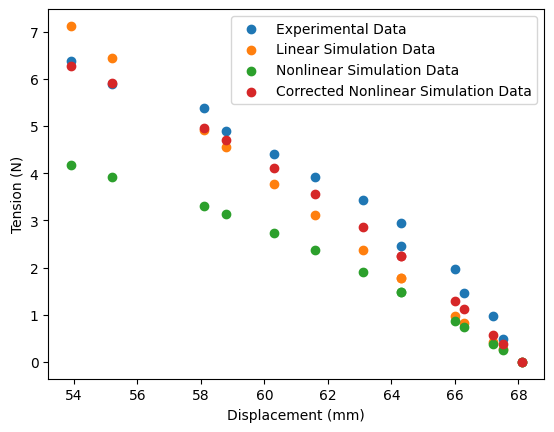

In [ ]:
plt.scatter(pos8, Forces, label="Experimental Data")
plt.scatter(pos8, tensions, label="Linear Simulation Data")
plt.scatter(pos8, tensions_NL_8, label="Nonlinear Simulation Data")
plt.scatter(pos8, k * s, label="Corrected Nonlinear Simulation Data")
plt.xlabel("Displacement (mm)")
plt.ylabel("Tension (N)")
plt.legend()
plt.show()
plt.close()

# Array 9
Sheets 18--20? \
Read in time, displacement, and force data for specimens 18--20


In [87]:
Disp_18, Force_18 = force_disp("Tables/Bambu TPU sheet_18.csv")
Disp_19, Force_19 = force_disp("Tables/Bambu TPU sheet_19.csv")
Disp_20, Force_20 = force_disp("Tables/Bambu TPU sheet_20.csv")

# plt.plot(Disp_18, Force_18, label="Specimen 18")
# plt.plot(Disp_19, Force_19, label="Specimen 19")
# plt.plot(Disp_20, Force_20, label="Specimen 20")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.legend()
# plt.show()
# plt.close()


In [88]:
# resample the data
f18 = interp1d(Disp_18, Force_18, kind='cubic', fill_value="extrapolate")
f19 = interp1d(Disp_19, Force_19, kind='cubic', fill_value="extrapolate")
f20 = interp1d(Disp_20, Force_20, kind='cubic', fill_value="extrapolate")

Force_18 = f18(Disp)
Force_19 = f19(Disp)
Force_20 = f20(Disp)

# plt.plot(Disp, Force_18, label="Specimen 18")
# plt.plot(Disp, Force_19, label="Specimen 19")
# plt.plot(Disp, Force_20, label="Specimen 20")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.legend()
# plt.show()
# plt.close()


In [89]:
# average 18--20
avg_9 = (Force_18 + Force_19 + Force_20) / 3.

# plt.plot(Disp, avg_9, label="Average Specimens 18--20")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Force (N)")
# plt.show()
# plt.close()


Ogden parameters: mu1 = 202.4997, alpha1 = 0.0921, mu2 = -2.2851, alpha2 = 8.7394, mu3 = -1.9306, alpha3 = -18.0737


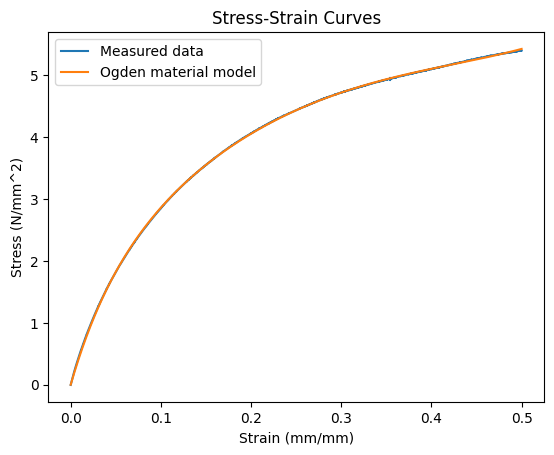

In [90]:
strain = Disp / 68.12 # mm/mm
stress = avg_9 / 1.2**2 # N/mm^2

node01 = Node(name="NodeA0", position=np.array([0., 0.]))
node02 = Node(name="NodeB0", position=np.array([1., 0.]))
connection0 = ConnectionNonlinear(nodes=[node01, node02], connection_type=string, material_properties=NonlinProps(strain=strain, stress=stress))
mu1 = connection0.material_properties.ogden_params[0]
alpha1 = connection0.material_properties.ogden_params[1]
mu2 = connection0.material_properties.ogden_params[2]
alpha2 = connection0.material_properties.ogden_params[3]
mu3 = connection0.material_properties.ogden_params[4]
alpha3 = connection0.material_properties.ogden_params[5]
print(f"Ogden parameters: mu1 = {mu1:.4f}, alpha1 = {alpha1:.4f}, mu2 = {mu2:.4f}, alpha2 = {alpha2:.4f}, mu3 = {mu3:.4f}, alpha3 = {alpha3:.4f}")
stretch = 1. + strain
stress_true = mu1 * (stretch**alpha1 - stretch**(-alpha1/2.))
stress_true += mu2 * (stretch**alpha2 - stretch**(-alpha2/2.))
stress_true += mu3 * (stretch**alpha3 - stretch**(-alpha3/2.))
stress_eng = stress_true / stretch

plt.plot(strain, stress, label="Measured data")
plt.plot(strain, stress_eng, label="Ogden material model")
plt.xlabel("Strain (mm/mm)")
plt.ylabel("Stress (N/mm^2)")
plt.title("Stress-Strain Curves")
plt.legend()
plt.show()
plt.close()

In [91]:
# Remeasure initial x position of Node 2 for Array 9
pos9 = [56.4] # initial position in mm
with open("Tables/Array 9.csv", "r", newline="") as csvfile9:
    reader = csv.DictReader(csvfile9)
    for i, row in enumerate(reader):
        if i % 3 == 0:  # every third row (starting with the first)
            pos9.append(float(row["Inner Distance (mm)"])) # mm
pos9 = np.array(pos9) # convert list to numpy array
pos9 = np.round(pos9, 1) # round to nearest tenth
pos9 += 11.7 # add the width of the TPU to the inner distance
print("Displacements for Array 9 (mm):", pos9)


Displacements for Array 9 (mm): [68.1 67.8 67.3 66.6 65.7 65.1 63.4 61.8 60.6 59.7 58.6 56.5 54.2 51.6]


In [92]:
# For Array 9 we used 500 to 801 by 10s
points = []
errors = []
min_error = np.inf
for num_points in range(202, 303, 1):
    points.append(num_points) # Store number of points used
    k_TPU = np.polyfit(Disp[:num_points+1], avg_9[:num_points+1], 1)[0] # Linear stiffness in N/mm
    if k_TPU < 0.01:
        k_TPU = 0.01 # prevent zero stiffness
    length_0_fl = 68.1 - k_TPU * (68.1 - 67.42) / k_fl

    node1 = Node(name="A", position=np.array([0., 0.]))
    node2 = Node(name="B", position=np.array([68.1, 0.]))
    node3 = Node(name="C", position=np.array([68.1, 68.1]))
    node4 = Node(name="D", position=np.array([0., 68.1]))
    nodes = [node1, node2, node3, node4] 

    connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, initial_length=length_0_fl, name="control_string")
    connection2 = Connection(nodes=[node2, node3], connection_type=string, stiffness=k_TPU, initial_length=67.42)
    connection3 = Connection(nodes=[node3, node4], connection_type=string, stiffness=k_TPU, initial_length=67.42)
    connection4 = Connection(nodes=[node4, node1], connection_type=string, stiffness=k_TPU, initial_length=67.42)
    connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
    connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
    connections = [connection1, connection2, connection3, connection4, connection5, connection6]

    pins = {"A": [True, True],
            "B": [False, True],
            "C": [False, False],
            "D": [False, False]}
        
    controls = [connection1]

    tensegrity_system = Tensegrity(nodes, connections, pins, controls)
    solver = TensegritySolver(tensegrity_system)
    solver.solve()

    length_change = 0.0 # mm, initialize length change
    tensions = []
    for i in range(len(pos9)):
        tensegrity_system.change_control_lengths(length_change)
        solver.solve()
        tensions.append(connection1.force)
        if i < len(pos9) - 1:
            length_change = pos9[i+1] - pos9[i] # mm

    error = np.sqrt(np.mean((np.array(tensions) - Forces)**2)) # RMSE
    errors.append(error)
    if error < min_error:
        min_error = error
        best_k = k_TPU
        best_num_points = num_points

# Return the value of N and the stiffness that gives the minimum error
print("Best number of points used:", best_num_points)
print("Best stiffness (N/mm):", best_k)
print("Best error:", min_error)


Best number of points used: 249
Best stiffness (N/mm): 1.0717151425725722
Best error: 0.4659228860585147


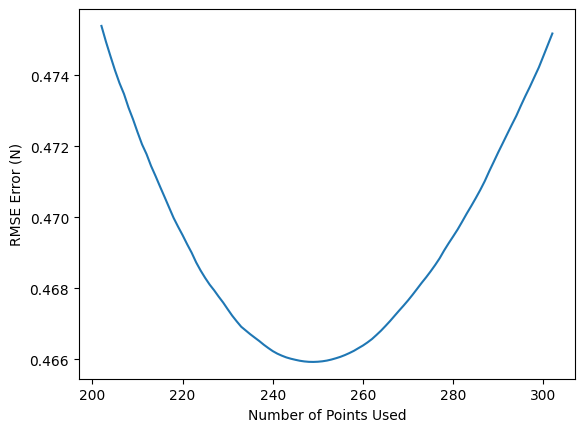

In [93]:
plt.plot(points, errors)
plt.xlabel("Number of Points Used")
plt.ylabel("RMSE Error (N)")
plt.show()
plt.close()

In [97]:
# plt.plot(pos9, Forces, 'o', label="Measured")
# plt.plot(pos9, tensions, 'o', label="Linear Simulated")
# plt.xlabel("x-position of node 2 (mm)")
# plt.ylabel("Tension (N)")
# plt.legend()
# plt.show()
# plt.close()

### Ogden Material Model

In [95]:
Node1 = Node(name="A", position=np.array([0., 0.]))
Node2 = Node(name="B", position=np.array([68.1, 0.]))
Node3 = Node(name="C", position=np.array([68.1, 68.1]))
Node4 = Node(name="D", position=np.array([0., 68.1]))
nodes = [Node1, Node2, Node3, Node4]

connection1 = Connection(nodes=[Node1, Node2], connection_type=string, stiffness=k_fl, name="control_string")
connection2 = ConnectionNonlinear(nodes=[Node2, Node3], connection_type=string, material_properties=NonlinProps(strain, stress), initial_length=67.42)
connection3 = ConnectionNonlinear(nodes=[Node3, Node4], connection_type=string, material_properties=NonlinProps(strain, stress), initial_length=67.42)
connection4 = ConnectionNonlinear(nodes=[Node4, Node1], connection_type=string, material_properties=NonlinProps(strain, stress), initial_length=67.42)
connection5 = Connection(nodes=[Node1, Node3], connection_type=bar, stiffness=k_Al)
connection6 = Connection(nodes=[Node2, Node4], connection_type=bar, stiffness=k_Al)
connections = [connection1, connection2, connection3, connection4, connection5, connection6]

pins = {"A": [True, True],
        "B": [False, True],
        "C": [False, False],
        "D": [False, False]}

controls = [connection1]

tensegrity_system = Tensegrity(nodes, connections, pins, controls)
solver = TensegritySolver(tensegrity_system)
solver.solve()

length_change = 0.0 # mm, initialize length change
tensions_NL_9 = []
for i in range(len(pos9)):
    tensegrity_system.change_control_lengths(length_change)
    solver.solve()
    tensions_NL_9.append(connection1.force)
    if i < len(pos9) - 1:
        length_change = pos9[i+1] - pos9[i] # mm

error = np.sqrt(np.mean((np.array(tensions_NL_9) - Forces)**2)) # RMSE

In [99]:
# plt.scatter(pos9, Forces, label="Experimental Data")
# plt.scatter(pos9, tensions, label="Linear Simulation Data")
# plt.scatter(pos9, tensions_NL_9, label="Nonlinear Simulation Data")
# plt.xlabel("Displacement (mm)")
# plt.ylabel("Tension (N)")
# plt.legend()
# plt.show()
# plt.close()

In [98]:
# Correction factor for nonlinear model
y1 = np.array(tensions)
s1 = np.array(tensions_NL_8)

y2 = np.array(tensions)
s2 = np.array(tensions_NL_9)

n1 = len(y1)
n2 = len(y2)

k = ((np.dot(s1, y1) / n1) + (np.dot(s2, y2) / n2)) / \
    ((np.dot(s1, s1) / n1) + (np.dot(s2, s2) / n2))

print(f"Correction factor k: {k:.4f}")

Correction factor k: 1.5033


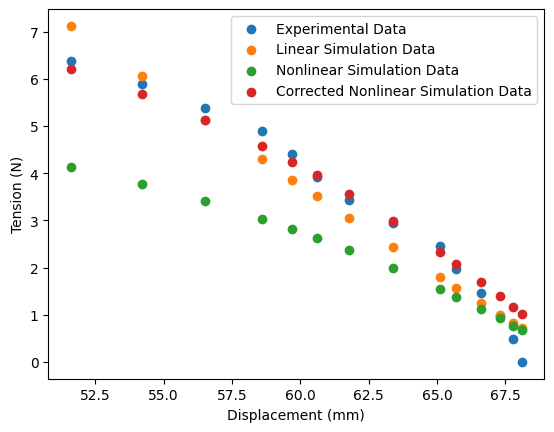

In [100]:
plt.scatter(pos9, Forces, label="Experimental Data")
plt.scatter(pos9, tensions, label="Linear Simulation Data")
plt.scatter(pos9, tensions_NL_9, label="Nonlinear Simulation Data")
plt.scatter(pos9, k * s2, label="Corrected Nonlinear Simulation Data")
plt.xlabel("Displacement (mm)")
plt.ylabel("Tension (N)")
plt.legend()
plt.show()
plt.close()

## Array 10
Sheets 21--23?

In [ ]:
# Read in time, displacement, and force data for specimens 21--23
# Convert to cable dimensions (Force in N, Displacement in mm)
Disp_21, Force_21 = force_disp("../Tables/Bambu TPU sheet_21.csv")
Disp_22, Force_22 = force_disp("../Tables/Bambu TPU sheet_22.csv")
Disp_23, Force_23 = force_disp("../Tables/Bambu TPU sheet_23.csv")

plt.plot(Disp_21, Force_21, label="Specimen 21")
plt.plot(Disp_22, Force_22, label="Specimen 22")
plt.plot(Disp_23, Force_23, label="Specimen 23")
plt.xlabel("Displacement (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()


In [ ]:

# %% [markdown]
# Resample the data


In [ ]:

# %%
f21 = interp1d(Disp_21, Force_21, kind='cubic', fill_value="extrapolate")
f22 = interp1d(Disp_22, Force_22, kind='cubic', fill_value="extrapolate")
f23 = interp1d(Disp_23, Force_23, kind='cubic', fill_value="extrapolate")

Force_21 = f21(Disp)
Force_22 = f22(Disp)
Force_23 = f23(Disp)

plt.plot(Disp, Force_21, label="Specimen 21")
plt.plot(Disp, Force_22, label="Specimen 22")
plt.plot(Disp, Force_23, label="Specimen 23")
plt.xlabel("Displacement (mm)")
plt.ylabel("Force (N)")
plt.legend()
plt.show()
plt.close()


In [ ]:

# %% [markdown]
# Average 21--23


In [ ]:

# %%
avg_10 = (Force_21 + Force_22 + Force_23) / 3.

plt.plot(Disp, avg_10, label="Average Specimens 21--23")
plt.xlabel("Displacement (mm)")
plt.ylabel("Force (N)")
plt.show()
plt.close()


In [ ]:

# %%
# Remeasure initial x position of Node 2 for Array 10
pos10 = [68.1*.95] # initial position in mm
with open("../Tables/Array 10.csv", "r", newline="") as csvfile10:
    reader = csv.DictReader(csvfile10)
    for i, row in enumerate(reader):
        if i % 3 == 0:  # every third row (starting with the first)
            pos10.append(float(row["Inner Distance (mm)"])) # mm
pos10 = np.array(pos10) # convert list to numpy array
pos10 = np.round(pos10, 1) # round to nearest tenth
# pos10 += 11.7 # add the width of the TPU to the inner distance
print("x-position of node 2 for Array 10 (mm):", pos10)


In [ ]:

# %%
plt.plot(pos10, Forces, 'o')
plt.xlabel("x-position of node 2 (mm)")
plt.ylabel("Load (N)")
plt.show()
plt.close()


In [ ]:

# %%
# For Array 10 we used 1751 to 2251 by 10s
points = []
ks = []
errors = []
min_error = np.inf
# plt.plot(pos10, Forces, 'o', label="Experimental Data")
for num_points in range(4600, 4700, 1):
    points.append(num_points) # Store number of points used
    k_TPU = np.polyfit(Disp[:num_points+1], avg_10[:num_points+1], 1)[0] # Linear stiffness in N/mm
    if k_TPU < 0.1:
        k_TPU = 0.1 # prevent zero stiffness
    # ks.append(k_TPU)
    length_0_fl = 68.1 - k_TPU * (68.1 - 64.7) / k_fl
    # print("Initial length of control string (mm):", length_0_fl)

    # Create the tensegrity system
    node1 = Node(name="A", position=np.array([0., 0.]))
    node2 = Node(name="B", position=np.array([68.1, 0.]))
    node3 = Node(name="C", position=np.array([68.1, 68.1]))
    node4 = Node(name="D", position=np.array([0., 68.1]))
    nodes = [node1, node2, node3, node4]

    connection1 = Connection(nodes=[node1, node2], connection_type=string, stiffness=k_fl, initial_length=length_0_fl, name="control_string")
    connection2 = Connection(nodes=[node2, node3], connection_type=string, stiffness=k_TPU, initial_length=64.7)
    connection3 = Connection(nodes=[node3, node4], connection_type=string, stiffness=k_TPU, initial_length=64.7)
    connection4 = Connection(nodes=[node4, node1], connection_type=string, stiffness=k_TPU, initial_length=64.7)
    connection5 = Connection(nodes=[node1, node3], connection_type=bar, stiffness=k_Al)
    connection6 = Connection(nodes=[node2, node4], connection_type=bar, stiffness=k_Al)
    connections = [connection1, connection2, connection3, connection4, connection5, connection6]

    pins = {"A": [True, True],
            "B": [False, True],
            "C": [False, False],
            "D": [False, False]}
    
    controls = [connection1]

    tensegrity_system = Tensegrity(nodes, connections, pins, controls)
    solver = TensegritySolver(tensegrity_system)
    solver.solve()

    length_change = 0.0 # mm, initialize length change
    tensions = []
    for i in range(len(pos10)):
        tensegrity_system.change_control_lengths(length_change)
        solver.solve()
        tensions.append(connection1.force)
        if i < len(pos10) - 1:
            length_change = pos10[i+1] - pos10[i] # mm

    # plt.plot(tensions, pos10)

    # calculate the RMS error or the position of Node 2
    error = np.sqrt(np.mean((np.array(tensions) - Forces)**2)) # Root Mean Square Error
    errors.append(error)
    if error < min_error:
        min_error = error
        best_k = k_TPU
        best_num_points = num_points
        best_tensions = tensions
    
    # plt.plot(pos10, tensions, 'o', label="Simulation Data")

# Return the value of N and the stiffness that gives the minimum error
print("Best number of points used:", best_num_points)
print("Best stiffness (N/mm):", best_k)
print("Best error:", min_error)

# plt.xlabel("x-position of node 2 (mm)")
# plt.ylabel("Tension (N)")
# plt.legend()
# plt.show()
# plt.close()


In [ ]:

# %%
plt.plot(points, errors)
plt.xlabel("Number of Points Used")
plt.ylabel("RMSE Error (N)")
plt.show()
plt.close()


In [ ]:

# %%
plt.plot(pos10, Forces, 'o', label="Experimental Data")
plt.plot(pos10, best_tensions, 'o', label="Simulation Data")
plt.xlabel("x-position of node 2 (mm)")
plt.ylabel("Tension (N)")
plt.legend()
plt.show()
plt.close()


